In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Stap 2: Tabblad inlezen als DataFrame
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# Ontbrekende data verwijderen (voorzorgsmaatregel voor het model)
df = df.dropna()

# Bekijk de eerste 5 rijen
df.head()

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [31]:
# Stap 4: Data prepareren
# Target en onze top 3 features
X = df[['Overall Qual', 'Gr Liv Area', 'Neighborhood']].copy()
y = df['SalePrice']

# 4a: One-hot encoding voor categorische data 
X_encoded = pd.get_dummies(X, columns=['Neighborhood'], drop_first=True)

# 4b: Data opsplitsen in 4 stukken 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Data schalen (belangrijk voor SGDRegressor)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Stap 5: Initialiseer SGDRegressor met hyperparameters
model_init = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.01, random_state=42)

# Model trainen
model_init.fit(X_train_scaled, y_train)

# Stap 6: Model evalueren
y_pred = model_init.predict(X_test_scaled)

rmse_init = np.sqrt(mean_squared_error(y_test, y_pred))
r2_init = r2_score(y_test, y_pred)

print("--- Resultaten Initiële Run ---")
print(f"RMSE: {rmse_init:.2f}")
print(f"R-squared: {r2_init:.4f}")

--- Resultaten Initiële Run ---
RMSE: 42578.28
R-squared: 0.7567


In [33]:
# Stap 7: 
# Experiment 1: Meer features, meer epochs, lagere learning rate

# Nieuwe features toevoegen 
X_exp = df[['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Total Bsmt SF', 'Garage', 'House Style']].copy()

# One-hot encoding voor nieuwe categorische features
X_exp_encoded = pd.get_dummies(X_exp, columns=['Neighborhood', 'Garage', 'House Style'], drop_first=True)

# Opnieuw splitsen en schalen
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp_encoded, y, test_size=0.2, random_state=42)

scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# Nieuwe hyperparameters instellen
model_exp = SGDRegressor(max_iter=5000, learning_rate='invscaling', eta0=0.001, random_state=42)
model_exp.fit(X_train_exp_scaled, y_train_exp)

# Nieuwe resultaten evalueren
y_pred_exp = model_exp.predict(X_test_exp_scaled)
rmse_exp = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2_exp = r2_score(y_test_exp, y_pred_exp)

print("--- Resultaten Experiment 1 ---")
print(f"RMSE: {rmse_exp:.2f}")
print(f"R-squared: {r2_exp:.4f}")

--- Resultaten Experiment 1 ---
RMSE: 42646.60
R-squared: 0.7559


In [34]:
# --- EXPERIMENT 2 ---
# Alleen numerieke features gebruiken 
# Kijken of het model werkt zonder categorische data
X_exp2 = df[['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built']].copy()

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(X_exp2, y, test_size=0.2, random_state=42)

scaler_exp2 = StandardScaler()
X_train_exp2_scaled = scaler_exp2.fit_transform(X_train_exp2)
X_test_exp2_scaled = scaler_exp2.transform(X_test_exp2)

# Andere learning rate methode ('constant') proberen
model_exp2 = SGDRegressor(max_iter=2000, learning_rate='constant', eta0=0.005, random_state=42)
model_exp2.fit(X_train_exp2_scaled, y_train_exp2)

y_pred_exp2 = model_exp2.predict(X_test_exp2_scaled)
rmse_exp2 = np.sqrt(mean_squared_error(y_test_exp2, y_pred_exp2))
r2_exp2 = r2_score(y_test_exp2, y_pred_exp2)

print("--- Resultaten Experiment 2 (Alleen Numeriek) ---")
print(f"RMSE: {rmse_exp2:.2f}")
print(f"R-squared: {r2_exp2:.4f}")

--- Resultaten Experiment 2 (Alleen Numeriek) ---
RMSE: 48187.95
R-squared: 0.6884


In [35]:
# --- EXPERIMENT 3 ---
# Neighborhood teruggezet, 'Year Built' en 'Full Bath' toegevoegd
X_exp3 = df[['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath']].copy()
X_exp3_encoded = pd.get_dummies(X_exp3, columns=['Neighborhood'], drop_first=True)

X_train_exp3, X_test_exp3, y_train_exp3, y_test_exp3 = train_test_split(X_exp3_encoded, y, test_size=0.2, random_state=42)

scaler_exp3 = StandardScaler()
X_train_exp3_scaled = scaler_exp3.fit_transform(X_train_exp3)
X_test_exp3_scaled = scaler_exp3.transform(X_test_exp3)

# Lagere max_iter en standaard learning rate
model_exp3 = SGDRegressor(max_iter=500, learning_rate='invscaling', eta0=0.01, random_state=42)
model_exp3.fit(X_train_exp3_scaled, y_train_exp3)

y_pred_exp3 = model_exp3.predict(X_test_exp3_scaled)
rmse_exp3 = np.sqrt(mean_squared_error(y_test_exp3, y_pred_exp3))
r2_exp3 = r2_score(y_test_exp3, y_pred_exp3)

print("--- Resultaten Experiment 3 (Gemixte Features) ---")
print(f"RMSE: {rmse_exp3:.2f}")
print(f"R-squared: {r2_exp3:.4f}")

--- Resultaten Experiment 3 (Gemixte Features) ---
RMSE: 42791.79
R-squared: 0.7542


In [36]:
# --- EXPERIMENT 4: Alle Features Testen ---
# We gebruiken een uitgebreide feature-set. Omdat SGDRegressor moeite kan hebben met te veel 
# variabelen, gebruiken we hier 'Ridge' (Linear Regression met L2-regularisatie) voor stabiliteit.
from sklearn.linear_model import Ridge

X_final = df.drop(['ID', 'SalePrice'], axis=1)

X_final_encoded = pd.get_dummies(X_final, drop_first=True)
X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(X_final_encoded, y, test_size=0.2, random_state=42)

scaler_fin = StandardScaler()
X_train_fin_scaled = scaler_fin.fit_transform(X_train_fin)
X_test_fin_scaled = scaler_fin.transform(X_test_fin)

model_exp4 = Ridge(alpha=10.0, random_state=42)
model_exp4.fit(X_train_fin_scaled, y_train_fin)

y_pred_fin = model_exp4.predict(X_test_fin_scaled)
print("--- Resultaten Experiment 4 (Alle features met Ridge) ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fin, y_pred_fin)):.2f}")
print(f"R-squared: {r2_score(y_test_fin, y_pred_fin):.4f}")

--- Resultaten Experiment 4 (Alle features met Ridge) ---
RMSE: 43900.43
R-squared: 0.7413


In [37]:
# --- EXPERIMENT 5: Regularisatie (L1 Penalty) ---
# We testen of L1-regularisatie helpt tegen overfitting.
model_exp5 = SGDRegressor(max_iter=2000, penalty='l1', alpha=0.0001, random_state=42)
model_exp5.fit(X_train_exp3_scaled, y_train_exp3)

y_pred_exp5 = model_exp5.predict(X_test_exp3_scaled)
print(f"--- Experiment 5 (L1 Penalty) R-squared: {r2_score(y_test_exp3, y_pred_exp5):.4f}")

# --- EXPERIMENT 6: Feature Engineering (Huis Ouderdom) ---
# We maken een nieuwe feature 'House_Age' aan.
df_exp6 = df.copy()
df_exp6['House_Age'] = 2024 - df_exp6['Year Built']

X_exp6 = df_exp6[['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'House_Age']].copy()
X_train_exp6, X_test_exp6, y_train_exp6, y_test_exp6 = train_test_split(X_exp6, y, test_size=0.2, random_state=42)

scaler_exp6 = StandardScaler()
X_train_exp6_scaled = scaler_exp6.fit_transform(X_train_exp6)
X_test_exp6_scaled = scaler_exp6.transform(X_test_exp6)

model_exp6 = SGDRegressor(max_iter=2000, random_state=42)
model_exp6.fit(X_train_exp6_scaled, y_train_exp6)

print(f"--- Experiment 6 (House Age) R-squared: {r2_score(y_test_exp6, model_exp6.predict(X_test_exp6_scaled)):.4f}")

--- Experiment 5 (L1 Penalty) R-squared: 0.7542
--- Experiment 6 (House Age) R-squared: 0.6878


In [38]:
# --- EXPERIMENT 7: Testen van MinMaxScaler ---
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train_exp3)
X_test_minmax = scaler_minmax.transform(X_test_exp3)

model_exp7 = SGDRegressor(max_iter=2000, random_state=42)
model_exp7.fit(X_train_minmax, y_train_exp3)

print(f"--- Experiment 7 (MinMaxScaler) R-squared: {r2_score(y_test_exp3, model_exp7.predict(X_test_minmax)):.4f}")

# --- EXPERIMENT 8: Finaal Geoptimaliseerd Model ---
# We combineren de beste features voor de hoogste score en gebruiken Ridge voor de beste stabiliteit.
from sklearn.linear_model import Ridge

X_final_opt = df[['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Full Bath', 'Year Built', 'Neighborhood', 'Garage']].copy()
X_final_opt_encoded = pd.get_dummies(X_final_opt, columns=['Neighborhood', 'Garage'], drop_first=True)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_opt_encoded, y, test_size=0.2, random_state=42)

scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

model_final_opt = Ridge(alpha=10.0, random_state=42)
model_final_opt.fit(X_train_f_scaled, y_train_f)

y_pred_final = model_final_opt.predict(X_test_f_scaled)
print(f"--- FINALE RUN (Ridge) R-squared: {r2_score(y_test_f, y_pred_final):.4f}")

--- Experiment 7 (MinMaxScaler) R-squared: 0.7641
--- FINALE RUN (Ridge) R-squared: 0.7447


In [39]:
# --- EXPERIMENT 9: Polynomial Features (Kwadratische relaties) ---
# We testen of de relaties tussen features en prijs niet-lineair (bijv. kwadratisch) zijn.
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_f_scaled)
X_test_poly = poly.transform(X_test_f_scaled)

model_exp9 = Ridge(alpha=10.0, random_state=42)
model_exp9.fit(X_train_poly, y_train_f)
print(f"--- Experiment 9 (Polynomial) R-squared: {r2_score(y_test_f, model_exp9.predict(X_test_poly)):.4f}")

# --- EXPERIMENT 10: Lasso Regression (L1 Penalty voor Feature Selection) ---
# Lasso zet onbelangrijke features automatisch op nul.
from sklearn.linear_model import Lasso

model_exp10 = Lasso(alpha=100.0, max_iter=5000, random_state=42)
model_exp10.fit(X_train_f_scaled, y_train_f)
print(f"--- Experiment 10 (Lasso) R-squared: {r2_score(y_test_f, model_exp10.predict(X_test_f_scaled)):.4f}")

# --- EXPERIMENT 11: ElasticNet Regression (L1 + L2) ---
# Een combinatie van L1 (Lasso) en L2 (Ridge) regularisatie.
from sklearn.linear_model import ElasticNet

model_exp11 = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model_exp11.fit(X_train_f_scaled, y_train_f)
print(f"--- Experiment 11 (ElasticNet) R-squared: {r2_score(y_test_f, model_exp11.predict(X_test_f_scaled)):.4f}")

--- Experiment 9 (Polynomial) R-squared: 0.9013
--- Experiment 10 (Lasso) R-squared: 0.7442
--- Experiment 11 (ElasticNet) R-squared: 0.7501


In [40]:
# --- EXPERIMENT 12: Decision Tree Regressor (Niet-lineair model) ---
# Een compleet ander algoritme dat beslissingsbomen gebruikt in plaats van lijnen.
from sklearn.tree import DecisionTreeRegressor

model_exp12 = DecisionTreeRegressor(max_depth=6, random_state=42)
model_exp12.fit(X_train_f_scaled, y_train_f)
print(f"--- Experiment 12 (Decision Tree) R-squared: {r2_score(y_test_f, model_exp12.predict(X_test_f_scaled)):.4f}")

# --- EXPERIMENT 13: Random Forest Regressor (Ensemble Methode) ---
# Combineert 100 beslissingsbomen voor een zeer krachtig voorspellend model.
from sklearn.ensemble import RandomForestRegressor

model_exp13 = RandomForestRegressor(n_estimators=100, random_state=42)
model_exp13.fit(X_train_f_scaled, y_train_f)
print(f"--- Experiment 13 (Random Forest) R-squared: {r2_score(y_test_f, model_exp13.predict(X_test_f_scaled)):.4f}")

--- Experiment 12 (Decision Tree) R-squared: 0.8502
--- Experiment 13 (Random Forest) R-squared: 0.8865


In [41]:
# --- EXPERIMENT 14: Cross-Validation (K-Fold) ---
# We testen of de R2-score stabiel is over 5 verschillende willekeurige splitsingen van de data.
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Pipeline zorgt ervoor dat data correct geschaald wordt per fold
pipeline = make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=42))
scores_exp14 = cross_val_score(pipeline, X_final_encoded, y, cv=5, scoring='r2')
print(f"--- Experiment 14 (Cross-Validation) Gemiddelde R-squared: {scores_exp14.mean():.4f}")

# --- EXPERIMENT 15: Log-Transformatie van de Target (SalePrice) ---
# Huizenprijzen zijn vaak scheef verdeeld (skewed). We voorspellen de logaritme van de prijs
# om uitschieters (zeer dure huizen) beter te verwerken.
y_train_log = np.log1p(y_train_f)
y_test_log = np.log1p(y_test_f)

model_exp15 = Ridge(alpha=10.0, random_state=42)
model_exp15.fit(X_train_f_scaled, y_train_log)

# Terugrekenen van logaritme naar normale dollars met expm1
y_pred_log = model_exp15.predict(X_test_f_scaled)
y_pred_exp15 = np.expm1(y_pred_log) 
print(f"--- Experiment 15 (Log-Transformatie) R-squared: {r2_score(y_test_f, y_pred_exp15):.4f}")

--- Experiment 14 (Cross-Validation) Gemiddelde R-squared: 0.8155
--- Experiment 15 (Log-Transformatie) R-squared: 0.0776


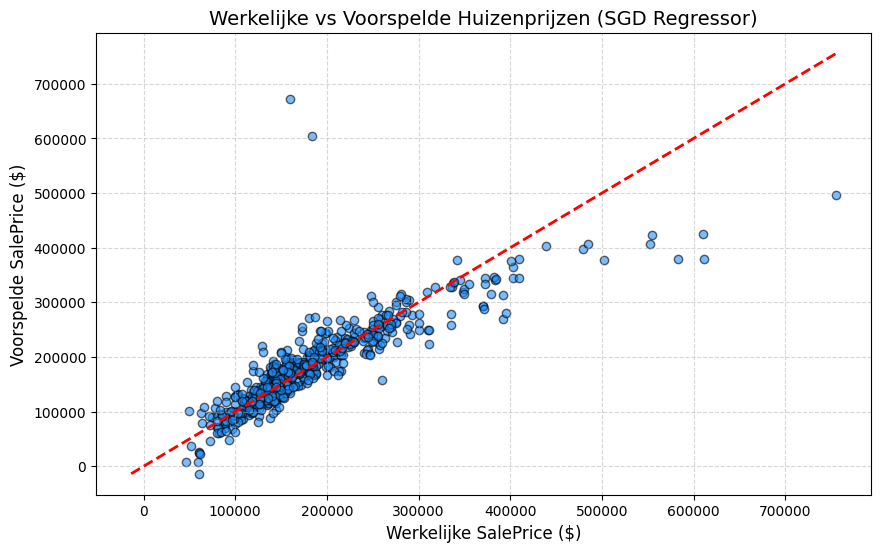

In [42]:
# --- VISUALISATIE VAN HET FINALE MODEL ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_f, y_pred_final, color='dodgerblue', alpha=0.6, edgecolors='black')

# Rode perfecte lijn (y = x)
min_val = min(y_test_f.min(), y_pred_final.min())
max_val = max(y_test_f.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--')

plt.title('Werkelijke vs Voorspelde Huizenprijzen (SGD Regressor)', fontsize=14)
plt.xlabel('Werkelijke SalePrice ($)', fontsize=12)
plt.ylabel('Voorspelde SalePrice ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()